# UFC Exploratory Data Analysis (EDA)

Welcome to Phase 3! This notebook visually explores our cleaned data (`ufc-ml-features.csv`).
In Machine Learning, EDA is crucial because it helps us:
1. Find out **which features** actually matter (correlation).
2. Spot **patterns** (e.g., do older fighters really lose more?).
3. Catch **mistakes** before feeding data to our algorithm.

Let's load the data!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look pretty
plt.style.use('dark_background')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)

# Load the data
df = pd.read_csv('../data/processed/ufc-ml-features.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7169, 132)


,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,Winner,no_of_rounds,B_current_lose_streak,...,R_Stance_Southpaw,R_Stance_Switch,B_Stance_Orthodox,B_Stance_Southpaw,B_Stance_Switch,B_Stance_Unknown,gender_MALE,better_rank_Blue,better_rank_Red,better_rank_neither
0,Israel Adesanya,Joe Pyfer,-130.0,102.0,76.9231,102.0000,2026-03-28,0,5,0,...,False,True,True,False,False,False,True,False,False,False
1,Alexa Grasso,Maycee Barber,124.0,-158.0,124.0000,63.2911,2026-03-28,1,3,0,...,False,False,False,False,True,False,False,False,False,False
2,Michael Chiesa,Niko Price,-901.0,550.0,11.0988,550.0000,2026-03-28,1,3,3,...,True,False,True,False,False,False,True,False,False,False
3,Julian Erosa,Lerryan Douglas,235.0,-320.0,235.0000,31.2500,2026-03-28,0,3,0,...,True,False,True,False,False,False,True,False,False,False
4,Mansur Abdul-Malik,Yousri Belgaroui,-158.0,124.0,63.2911,124.0000,2026-03-28,0,3,0,...,False,False,True,False,False,False,True,False,False,False


## 1. Feature Correlation (What matters most?)

A **Correlation Matrix** mathematically measures how closely two variables move together:
*   **+1.0:** Perfect positive correlation (As X goes up, Y goes up).
*   **-1.0:** Perfect negative correlation (As X goes up, Y goes down).
*   **0.0:** No relationship at all.

Our target variable is `Winner` (1 = Red, 0 = Blue). Let's see which features correlate most strongly with Red winning!

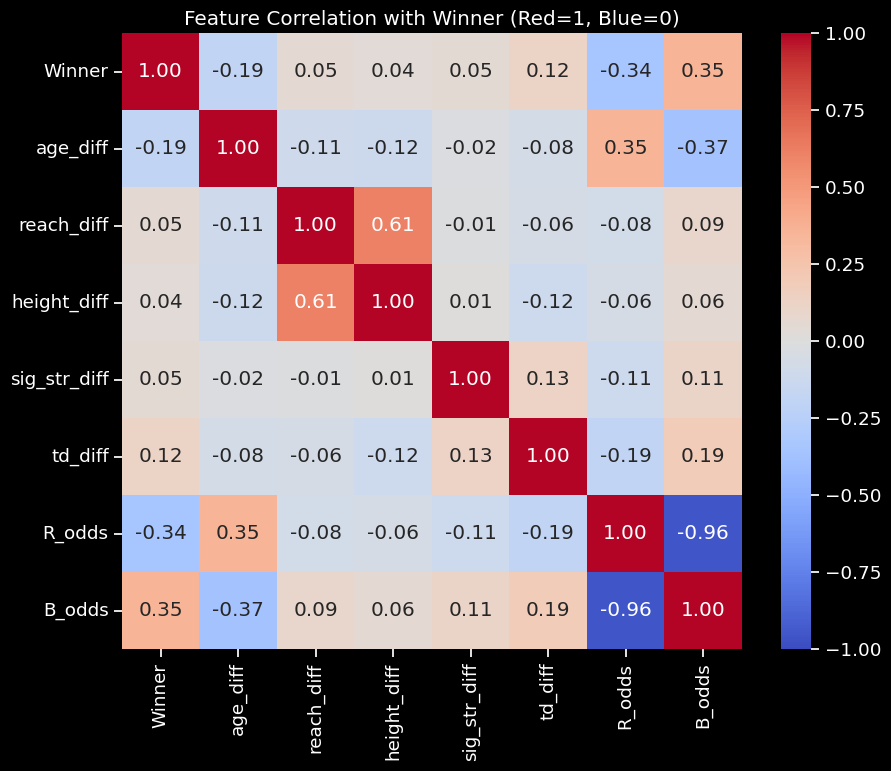

Correlation with Winner (Top 5 Positive, Top 5 Negative):
B_odds          0.352766
td_diff         0.120011
reach_diff      0.054791
sig_str_diff    0.052518
height_diff     0.036527
age_diff       -0.188959
R_odds         -0.344786
Name: Winner, dtype: float64


In [2]:
# Select a subset of features to keep the heatmap readable
features_to_check = [
    'Winner', 'age_diff', 'reach_diff', 'height_diff', 
    'sig_str_diff', 'td_diff', 'R_odds', 'B_odds'
]

# Calculate correlations
corr = df[features_to_check].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Feature Correlation with Winner (Red=1, Blue=0)")
plt.show()

# Focus strictly on the target variable
print("Correlation with Winner (Top 5 Positive, Top 5 Negative):")
corr_with_target = corr['Winner'].drop('Winner').sort_values(ascending=False)
print(corr_with_target)

## 2. The Impact of Age Advantages

MMA is a young person's game, or so they say. Let's look at `age_diff` (`R_age` - `B_age`). 
*   If `age_diff` is **negative**, Red is *younger*. 
*   If `age_diff` is **positive**, Red is *older*.

C:\Users\suriy\AppData\Local\Temp\ipykernel_46296\1373796261.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=age_win_rates.index, y=age_win_rates.values, palette='viridis')


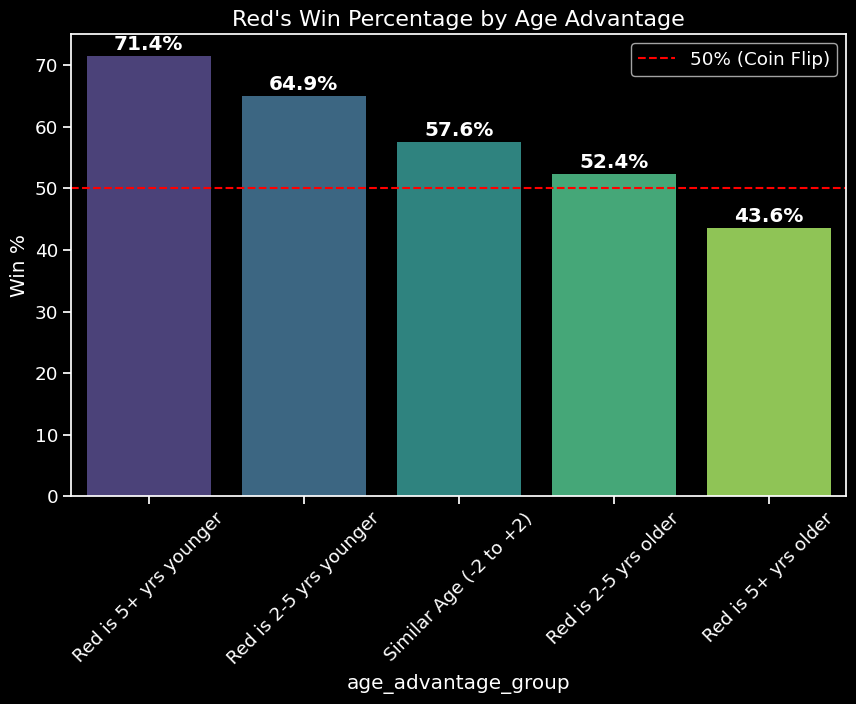

In [3]:
# Create age brackets to see win rate
df['age_advantage_group'] = pd.cut(df['age_diff'], 
                                   bins=[-20, -5, -2, 2, 5, 20], 
                                   labels=['Red is 5+ yrs younger', 'Red is 2-5 yrs younger', 
                                           'Similar Age (-2 to +2)', 
                                           'Red is 2-5 yrs older', 'Red is 5+ yrs older'])

# Calculate Red's win rate in each bracket
age_win_rates = df.groupby('age_advantage_group', observed=False)['Winner'].mean() * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=age_win_rates.index, y=age_win_rates.values, palette='viridis')
plt.title("Red's Win Percentage by Age Advantage", fontsize=16)
plt.ylabel("Win %")
plt.axhline(50, color='red', linestyle='--', label='50% (Coin Flip)')
plt.xticks(rotation=45)
plt.legend()

# Add percentages on top of bars
for i, v in enumerate(age_win_rates.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

plt.show()

## 3. The Impact of Reach Advantages

Does having longer arms actually win fights? Let's look at `reach_diff` (`R_Reach_cms` - `B_Reach_cms`).
*   If `reach_diff` is **positive**, Red has a reach advantage.

C:\Users\suriy\AppData\Local\Temp\ipykernel_46296\1918555068.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=reach_win_rates.index, y=reach_win_rates.values, palette='magma')


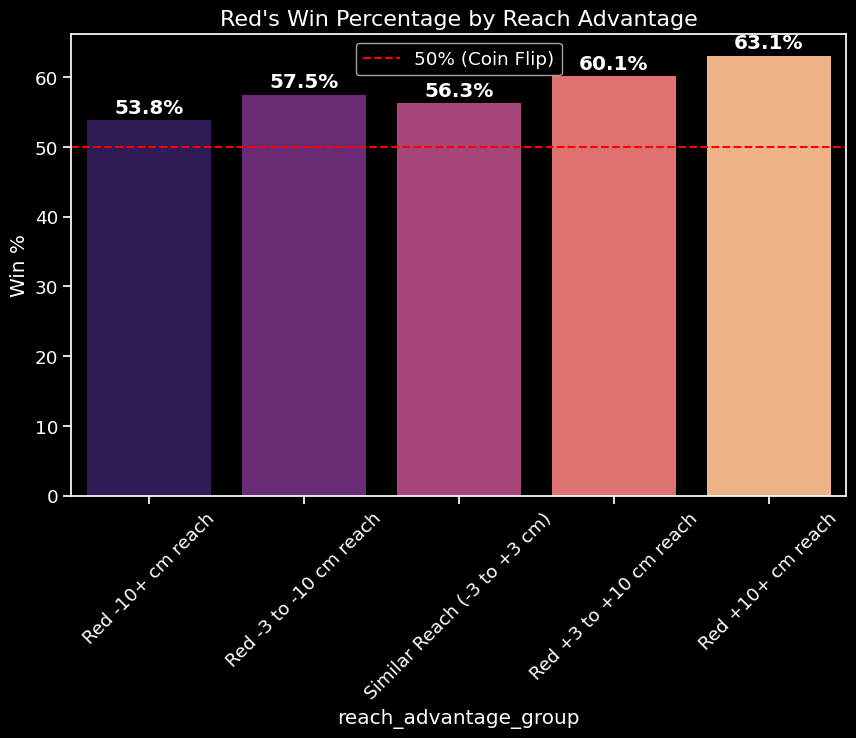

In [4]:
# Create reach brackets
df['reach_advantage_group'] = pd.cut(df['reach_diff'], 
                                   bins=[-30, -10, -3, 3, 10, 30], 
                                   labels=['Red -10+ cm reach', 'Red -3 to -10 cm reach', 
                                           'Similar Reach (-3 to +3 cm)', 
                                           'Red +3 to +10 cm reach', 'Red +10+ cm reach'])

# Calculate Red's win rate in each bracket
reach_win_rates = df.groupby('reach_advantage_group', observed=False)['Winner'].mean() * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=reach_win_rates.index, y=reach_win_rates.values, palette='magma')
plt.title("Red's Win Percentage by Reach Advantage", fontsize=16)
plt.ylabel("Win %")
plt.axhline(50, color='red', linestyle='--', label='50% (Coin Flip)')
plt.xticks(rotation=45)
plt.legend()

for i, v in enumerate(reach_win_rates.values):
    if not np.isnan(v):
        ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

plt.show()

## ML Takeaways

Look at the charts above! What does it tell our machine learning model?
1.  **Odds matter most:** `R_odds` and `B_odds` are heavily correlated with the `Winner`. Vegas knows what they are doing!
2.  **Age is a massive factor:** When Red is 5+ years younger, their win rate jumps drastically above 50%. When Red is 5+ years older, their win rate plummets. 
3.  **Reach is less important than Age:** The differences in win rates across the reach advantage groups are much flatter compared to the age advantage groups.

**Next Steps:** Our Baseline Logistic Regression model learned all of this automatically! In Phase 5, we will use **XGBoost** to see if we can extract even deeper patterns out of these features.